# HOMEWORK 14

In this homework we will be working with the Fashion MNIST dataset. You will be given a classifier which suffers from considerable overfitting. Your objective will be to employ regularization techniques to mitigate the overfitting problem.

Let's start with the usual imports.

In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D, BatchNormalization
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Dataset

The MNIST fashgion dataset [link](https://github.com/zalandoresearch/fashion-mnist) was build by Zalando Reasearch tem consists of monochrome images of different type of clothing, namely:
* 0	T-shirt/top
* 1	Trouser
* 2	Pullover
* 3	Dress
* 4	Coat
* 5	Sandal
* 6	Shirt
* 7	Sneaker
* 8	Bag
* 9	Ankle boot

It is also one of the Keras built-in datasets. Let's load the images and quickly inspect it.

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Dataset params
num_classes = 10
size = x_train.shape[1]

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train set:    60000 samples
Test set:     10000 samples
Sample dims:  (60000, 28, 28)


Let's visualise some random samples.

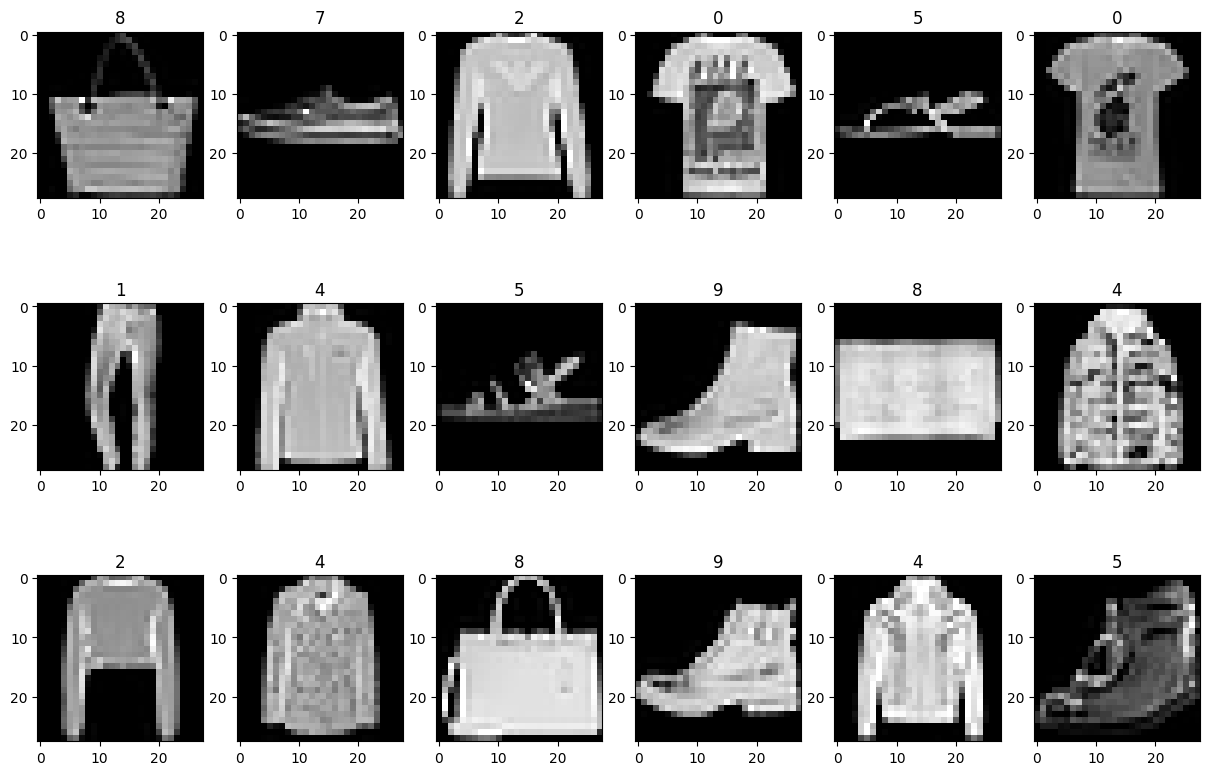

In [4]:
cnt = 1
for r in range(3):
    for c in range(6):
        idx = np.random.randint(len(x_train))
        plt.subplot(3,6,cnt)
        plt.imshow(x_train[idx, ...], cmap='gray')
        plt.title(y_train[idx])
        cnt = cnt + 1

### Building the Classifier

We are now going to build the baseline classifier that you will use throughout this homework.

In [5]:
# Data normalization
x_train = x_train/255
x_test = x_test/255

In [6]:
inputs = Input(shape=(28, 28, 1))
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = Flatten()(net)
net = Dense(128)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,002 (12.26 MB)

 Trainable params: 3,213,002 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
epochs = 50
batch_size = 64

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 65s 68ms/step - accuracy: 0.8217 - loss: 0.5475 - val_accuracy: 0.8831 - val_loss: 0.3225
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - accuracy: 0.9019 - loss: 0.2723 - val_accuracy: 0.8893 - val_loss: 0.3029
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - accuracy: 0.9187 - loss: 0.2252 - val_accuracy: 0.8938 - val_loss: 0.3070
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 70ms/step - accuracy: 0.9300 - loss: 0.1933 - val_accuracy: 0.8930 - val_loss: 0.3223
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 68ms/step - accuracy: 0.9413 - loss: 0.1661 - val_accuracy: 0.8945 - val_loss: 0.3324
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.9494 - loss: 0.1413 - val_accuracy: 0.8941 - val_loss: 0.3551
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.9566 - loss: 0.1237 - val_accuracy: 0.8937 - val_loss: 0.3799
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - accuracy: 0.9607 - loss: 0.1121 - 

Train Acc      0.9935333132743835
Validation Acc 0.8791999816894531


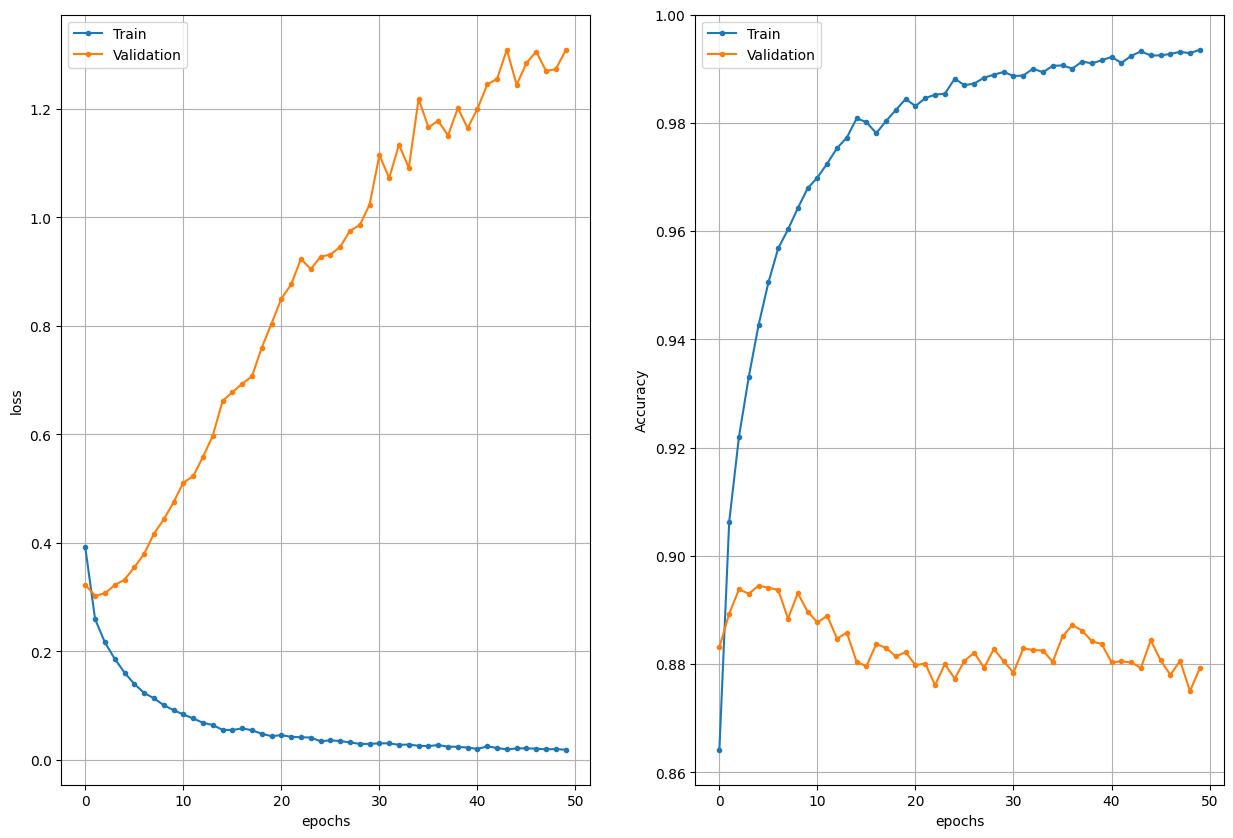

In [8]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])

    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])

plot_history(history)

As you can see, the classifier suffers from massive overfitting. The validation accuracy is around 88% while the training accuracy is close to 1.

### Combat the Overfitting!

Now it is your turn. Use the classifier as a baseline, include some regularization techniques and try to improve the classification performance. You can try any techniques you might see fit, e.g.,
* Dropout
* Batch normalization
* Weight regularization
* Data augmentation
* Early stopping
* Pooling
* Reducing the number of parameters (the size of the network)
* ...

There are to objective you shall fulfill in order to successfully complete this homework:
* The validation accuracy shall be above 91%
* Your network (with all the regularizations applied) shall **not** be larger than the baseline

In [47]:
# Modify the baseline classifier in order to reduce the overfitting and make the performance more robust

inputs = Input(shape=(28, 28, 1))
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = BatchNormalization()(net)
net = Dropout(0.2)(net)
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = BatchNormalization()(net)
net = Dropout(0.2)(net)
net = Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = BatchNormalization()(net)
net = Dropout(0.2)(net)
net = Flatten()(net)
net = Dense(96)(net)
net = Dropout(0.5)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 7, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 96)             │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,938 (331.79 KB)

 Trainable params: 84,682 (330.79 KB)

 Non-trainable params: 256 (1.00 KB)

**From student**: In data augmentation i would like to try adjust brightness of non-black pixels. In the dataset i observed that different clothes have different brightnesses so i could use this in augmentation.

In [48]:
from sklearn.utils import shuffle

kernel = np.array([[-1, -1, -1],
                   [-1,  9, -1],
                   [-1, -1, -1]])

def datagen(x, y, batch_size):
    num_samples = len(y)
    while True:
        for idx in range(0, num_samples, batch_size):
            x_ = x[idx:idx + batch_size, ...]
            y_ = y[idx:idx + batch_size]

            if len(y_) < batch_size:
                x, y = shuffle(x, y)
                break

            # Augmentation
            for idx_aug in range(batch_size):
                decision = np.random.rand()
                x_aug = x_[idx_aug, ...]
                adj = x_aug[x_aug > 0].min() // 2
                max = x_aug.max()

                if decision < 0.2:
                  # make image less brighter
                   x_aug[x_aug > 0] -= adj

                if decision > 0.8:
                  # make image less brighter
                   x_aug[x_aug > 0] += adj

                x_aug[x_aug>1.0] = 1.0

                x_[idx_aug] = x_aug

            yield x_, y_

**From student**: Also I would like to apply early stopping.

In [51]:
from tensorflow.keras.callbacks import EarlyStopping

# since the goal is to increase validation accuracy to 91%, the early stopping callback would monitor it
# stop when accuracy would be decreasing, wait for 8 epochs before the stop if it's not improving
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    mode='max',
    verbose=1,
    baseline=0.83)

early_stop_goal = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    mode='max',
    verbose=1,
    restore_best_weights=True,
    baseline=0.91,
    start_from_epoch=40)

# also add early stop for loss function
loss_stop = EarlyStopping(monitor='loss', mode='min', verbose=1, patience=5)

In [52]:
# Train the network
epochs = 50
batch_size = 64
steps_per_epoch = len(y_train) // batch_size
generator=datagen(x_train, y_train, batch_size)

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(generator, steps_per_epoch=steps_per_epoch, epochs=epochs, validation_data=(x_test, y_test), callbacks=[early_stop, early_stop_goal, loss_stop])

Epoch 1/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 84s 87ms/step - accuracy: 0.7951 - loss: 0.5806 - val_accuracy: 0.8594 - val_loss: 0.3884
Epoch 2/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 78s 83ms/step - accuracy: 0.8453 - loss: 0.4298 - val_accuracy: 0.8753 - val_loss: 0.3497
Epoch 3/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 75s 80ms/step - accuracy: 0.8628 - loss: 0.3874 - val_accuracy: 0.8737 - val_loss: 0.3342
Epoch 4/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 76s 82ms/step - accuracy: 0.8708 - loss: 0.3633 - val_accuracy: 0.8601 - val_loss: 0.3875
Epoch 5/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 78s 83ms/step - accuracy: 0.8762 - loss: 0.3468 - val_accuracy: 0.8912 - val_loss: 0.2999
Epoch 6/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 77s 82ms/step - accuracy: 0.8813 - loss: 0.3352 - val_accuracy: 0.8917 - val_loss: 0.2968
Epoch 7/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 76s 82ms/step - accuracy: 0.8848 - loss: 0.3199 - val_accuracy: 0.8940 - val_loss: 0.2928
Epoch 8/50
937/937 ━━━━━━━━━━━━━━━━━━━━ 78s 83ms/step - accuracy: 0.8900 - loss: 0.3072 - 

Train Acc      0.918573260307312
Validation Acc 0.9126999974250793


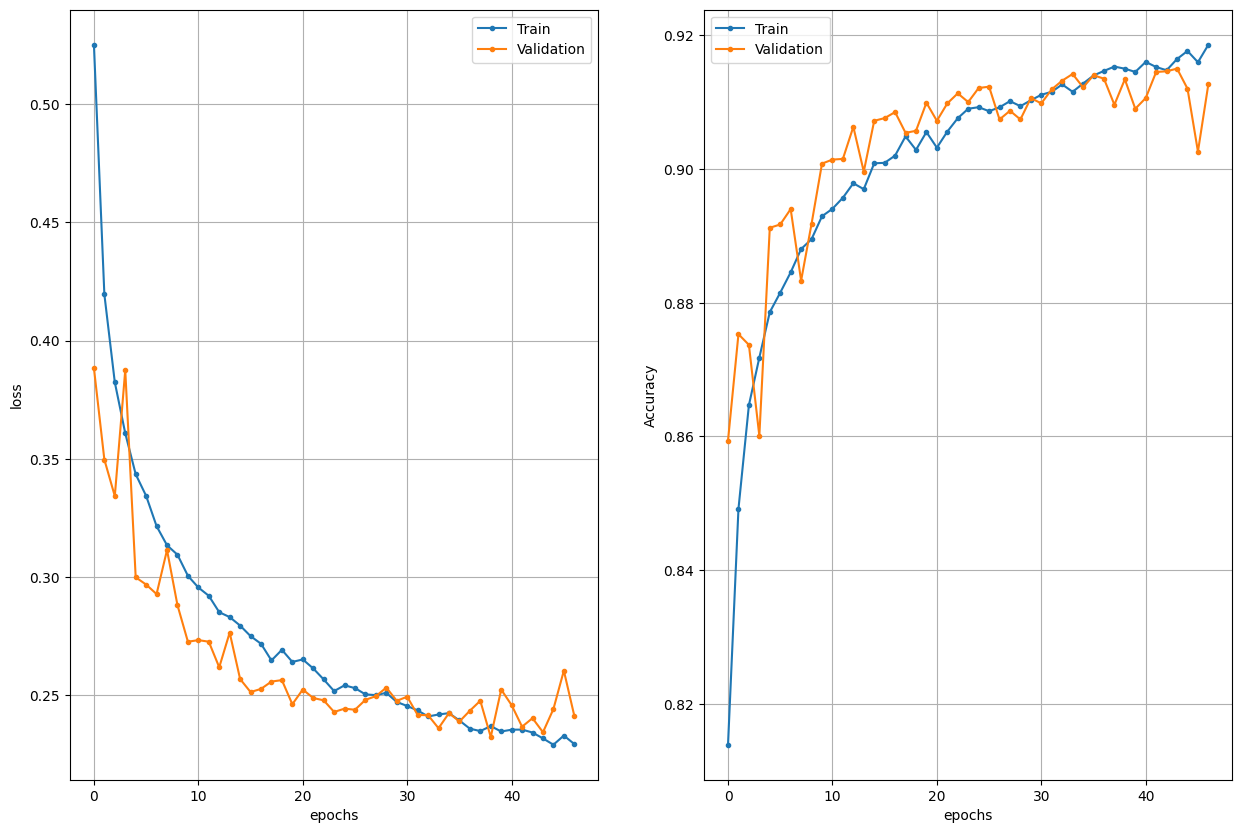

In [53]:
# Show the results

def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])

    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])

plot_history(history)

Validation accuracy is improved to target value of 91% and it's very close to training accuracy. Also the size of model is reduced.

### Questions

* What have you done in order to improve the performance?

  Answer: The modifications that i applied:


  1.   Reduced the number of neurons in the final hidden dense layer from 128 to 96 in order to reduce the concetration of the most parameters in one layer.
  2.   Add additional convolutional layers with 32 and 64 filters and add max pooling layers after each convolutional layer.
  3. Added dropouts after convolution layers and before final layer.
  4. Added batch normalization before dropout layers.
  5. Added early stopping callback to stop when maximum accuracy is achieved.
  6. Applied data augmentation to adjust brightness.


* Have you tried configurations that did not work out?

  Answer: In the initial configuration i applied data augmentation with blurring and sharpening. Later configuration have 2 convolutional layers instead of 3 and dropout layers after each convolution. Also i changed the patience of early stopping from 3 to 5 and start from epoch 10 to give more room for accuracy improvement. And dense layer had 64 neurons instead of 96.